In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element
from petsc4py import PETSc


from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, rhs, sym)

from ns_helpers import (create_noslip_dirichlet_bc, 
                        constant_pressure_bc, 
                        velocity_profile_bc)

# Mesh
x_lim = 2.0
y_lim = 1.0
x_res = 50
y_res = 25

pts = ((0.0, 0.0), (x_lim, y_lim))
domain = mesh.create_rectangle(MPI.COMM_WORLD, pts, (x_res, y_res), mesh.CellType.triangle)

# Spaces
V = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 2, shape=(2,)))
Q = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1))

# Temporal parameters
t = 0.0
T = 10.0
num_steps = 50
dt = T / num_steps
time_steps = np.arange(t, T, dt)

# Trial and test functions
u = TrialFunction(V)

v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

# Functions
u_n = Function(V)
u_tent = Function(V)
u_new = Function(V)
p_n = Function(Q)
p_new = Function(Q)
f = Constant(domain, PETSc.ScalarType((0.0, 0.0)))

# Define strain-rate tensor
def epsilon(u):
    return sym(nabla_grad(u))

# Define stress tensor
def sigma(u, p):
    return 2 * mu * epsilon(u) - p * Identity(len(u))

u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(domain)
f = Constant(domain, PETSc.ScalarType((0, 0)))
k = Constant(domain, PETSc.ScalarType(dt))
mu = Constant(domain, PETSc.ScalarType(1.5e-5))
rho = Constant(domain, PETSc.ScalarType(1.2))

# Define the variational problem for the first step
p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(mu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))

# Define variational problem for step 2
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_new) * q * dx)

# Define variational problem for step 3
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_new, v) * dx - k * dot(nabla_grad(p_new - p_n), v) * dx)

# Boundary conditions
def no_slip_bdry(x: np.ndarray) -> np.ndarray:
    top_bottom =  np.logical_or(np.isclose(x[1], y_lim), np.isclose(x[1], 0.0))
    lower_left = np.logical_and(np.isclose(x[0], 0.0), x[1] < y_lim / 2.0)
    upper_right = np.logical_and(np.isclose(x[0], x_lim), x[1] > y_lim / 2.0)
    side_no_slip = np.logical_or(lower_left, upper_right)

    return np.logical_or(side_no_slip, top_bottom)

def inflow(x: np.ndarray) -> np.ndarray:
    return np.logical_and(np.isclose(x[0], 0.0), x[1] > y_lim / 2.0)

def outflow(x: np.ndarray) -> np.ndarray:
    return np.logical_and(np.isclose(x[0], x_lim), x[1] < y_lim / 2.0)

def inflow_velocity_profile(x: np.ndarray) -> np.ndarray:
    y_centered = (x[1] - y_lim/2) / (y_lim/2)
    u_val = np.where(
        inflow(x),
        4.0 * (1 - y_centered) * y_centered,
        0.0
    )
    return np.stack((u_val, np.zeros_like(x[1])))

bc_no_slip = create_noslip_dirichlet_bc(V, no_slip_bdry)
bc_in = velocity_profile_bc(V, inflow, inflow_velocity_profile)
bc_out = constant_pressure_bc(Q, outflow)

tentative_velocity_problem = LinearProblem(a1, L1, [bc_no_slip, bc_in], u_tent, 
                                           petsc_options={"ksp_type": "gmres"})
pressure_problem = LinearProblem(a2, L2, [bc_out], p_new)
velocity_correction_problem = LinearProblem(a3, L3, [bc_no_slip, bc_in], u_new)

# Error form
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V) 
l2_norm_squared = form(inner(u_diff, u_diff) * dx)
l2_errors = np.zeros(num_steps)
it_conv = np.inf
for idx, t_i in enumerate(time_steps):
    t = t_i
    tentative_velocity_problem.solve()
    pressure_problem.solve()
    velocity_correction_problem.solve()
    u_diff.x.array[:] = u_new.x.array - u_n.x.array
    l2_errors[idx] = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    
    if t_i > time_steps[0]:
        if abs(l2_errors[idx] - l2_errors[idx - 1]) < 1e-10:
            it_conv = idx
            print(f"Converged after {idx + 1} iterations.")
            print(f"Final L2 err = {l2_errors[it_conv]:.2e}")
            
            break
    u_n.x.array[:] = u_new.x.array
    p_n.x.array[:] = p_new.x.array
    sys.stdout.flush()

if it_conv == np.inf:
    print(f"Reached max number of iterations ({num_steps}). L2 Error: {l2_errors[-1]:.2e}")


Converged after 23 iterations.
Final L2 err = 2.26e-09


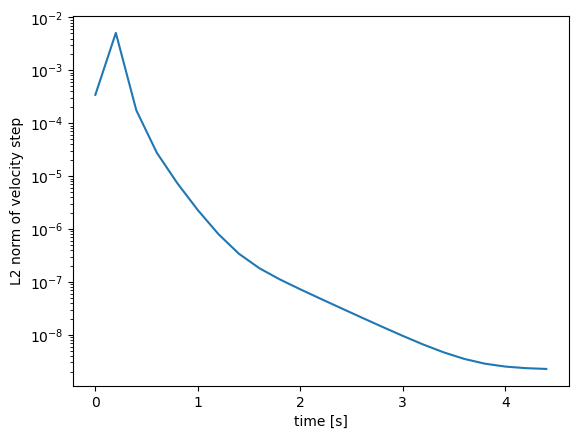

In [5]:
if it_conv == np.inf:
    plt.semilogy(time_steps, l2_errors)
else:
    plt.semilogy(time_steps[0:it_conv+1], l2_errors[0:it_conv+1])
plt.xlabel("time [s]")
plt.ylabel("L2 norm of velocity step")
sys.stdout.flush()

In [6]:
output_dir =  Path("./output_results").resolve()

dom_cell = domain.basix_cell()
V_u_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))
V_p_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1))

u_vis = Function(V_u_vis)
p_vis = Function(V_p_vis)

u_vis.interpolate(u_new)
p_vis.interpolate(p_new)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "velocity.xdmf", "w") as f_u:
    f_u.write_mesh(domain)
    u_vis.name = "velocity"
    f_u.write_function(u_vis, 0)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "pressure.xdmf", "w") as f_p:
    f_p.write_mesh(domain)
    p_vis.name = "pressure"
    f_p.write_function(p_vis, 0)
